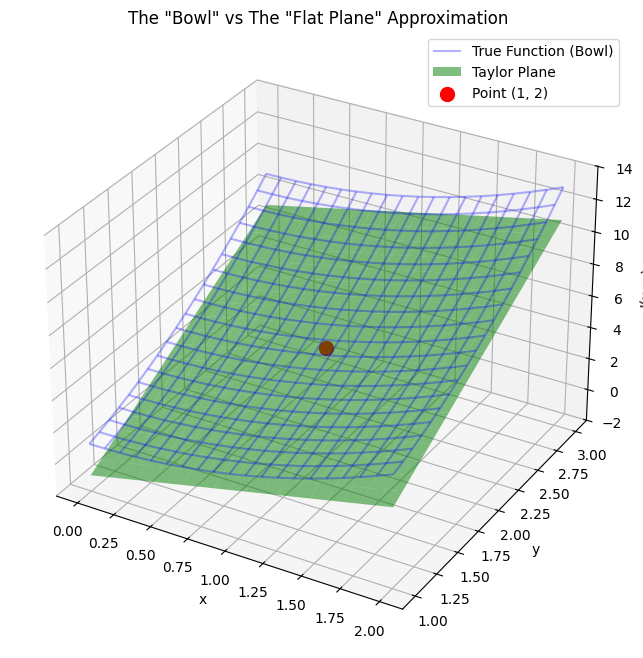

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Bowl (True Function)
def J(x, y):
    return x**2 + y**2

# 2. Define the Plane (Taylor Approximation)
# Approximating near (1, 2) where J=5, grad=[2, 4]
def Plane(dx, dy):
    return 5 + 2*dx + 4*dy

# Grid for plotting
x = np.linspace(0, 2, 20)
y = np.linspace(1, 3, 20)
X, Y = np.meshgrid(x, y)

# True Surface Z
Z_bowl = J(X, Y)

# Approximate Surface Z (Calculated using deltas from 1, 2)
# dx = X - 1, dy = Y - 2
Z_plane = Plane(X - 1, Y - 2)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Bowl (Wireframe)
ax.plot_wireframe(X, Y, Z_bowl, color='blue', alpha=0.3, label='True Function (Bowl)')

# Plot Plane (Surface)
ax.plot_surface(X, Y, Z_plane, color='green', alpha=0.5, label='Taylor Plane')

# Point of contact
ax.scatter(1, 2, 5, color='red', s=100, label='Point (1, 2)')
plt.legend()
ax.set_title('The "Bowl" vs The "Flat Plane" Approximation')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('J(x, y)')
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/var/folders/tg/9kqvmvx53qd8zhrspxc_pgf80000gn/T/ipykernel_28879/3915100189.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.015, label='Gradient ($\mathbf{u}$)')
/var/folders/tg/9kqvmvx53qd8zhrspxc_pgf80000gn/T/ipykernel_28879/3915100189.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.quiver(0, 0, v_ascent[0], v_ascent[1], angles='xy', scale_units='xy', scale=1, color='green', alpha=0.6, width=0.01, label='Ascent ($\mathbf{v}$, $\theta=0^\circ$)')
/var/folders/tg/9kqvmvx53qd8zhrspxc_pgf80000gn/T/ipykernel_28879/3915100189.py:35: SyntaxWarning: invalid escape sequence '\m'
  plt.quive

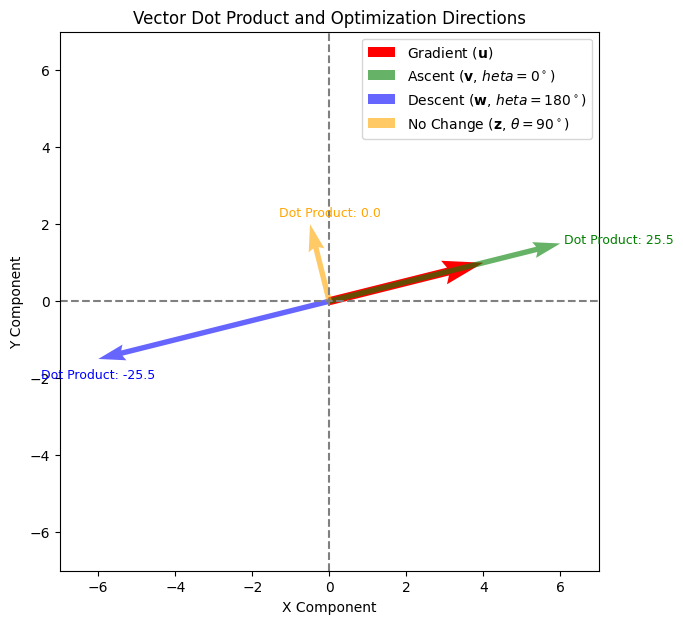

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Gradient Vector (u)
u = np.array([4, 1])

# 2. Define the Test Step Vectors (v)
# v_ascent: Parallel (0 degrees, Max Positive Dot Product)
v_ascent = u * 1.5 
# v_descent: Anti-Parallel (180 degrees, Max Negative Dot Product)
v_descent = -u * 1.5 
# v_perpendicular: Orthogonal (90 degrees, Zero Dot Product) - Rotate u by 90 degrees [-y, x]
v_perpendicular = np.array([-u[1], u[0]]) * 0.5 

# Calculate the dot products for annotations
dot_ascent = np.dot(u, v_ascent)
dot_descent = np.dot(u, v_descent)
dot_perpendicular = np.dot(u, v_perpendicular)

# --- Plotting ---
plt.figure(figsize=(7, 7))
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlim(-7, 7)
plt.ylim(-7, 7)

# Plot Gradient Vector (u)
plt.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.015, label='Gradient ($\mathbf{u}$)')

# Plot Ascent Vector (0 deg)
plt.quiver(0, 0, v_ascent[0], v_ascent[1], angles='xy', scale_units='xy', scale=1, color='green', alpha=0.6, width=0.01, label='Ascent ($\mathbf{v}$, $\theta=0^\circ$)')
plt.text(v_ascent[0] + 0.1, v_ascent[1], f'Dot Product: {dot_ascent:.1f}', color='green', fontsize=9)

# Plot Descent Vector (180 deg)
plt.quiver(0, 0, v_descent[0], v_descent[1], angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.6, width=0.01, label='Descent ($\mathbf{w}$, $\theta=180^\circ$)')
plt.text(v_descent[0] - 1.5, v_descent[1] - 0.5, f'Dot Product: {dot_descent:.1f}', color='blue', fontsize=9)

# Plot Perpendicular Vector (90 deg)
plt.quiver(0, 0, v_perpendicular[0], v_perpendicular[1], angles='xy', scale_units='xy', scale=1, color='orange', alpha=0.6, width=0.01, label=r'No Change ($\mathbf{z}$, $\theta=90^\circ$)')
plt.text(v_perpendicular[0] - 0.8, v_perpendicular[1] + 0.2, f'Dot Product: {dot_perpendicular:.1f}', color='orange', fontsize=9)

plt.title('Vector Dot Product and Optimization Directions')
plt.xlabel('X Component')
plt.ylabel('Y Component')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

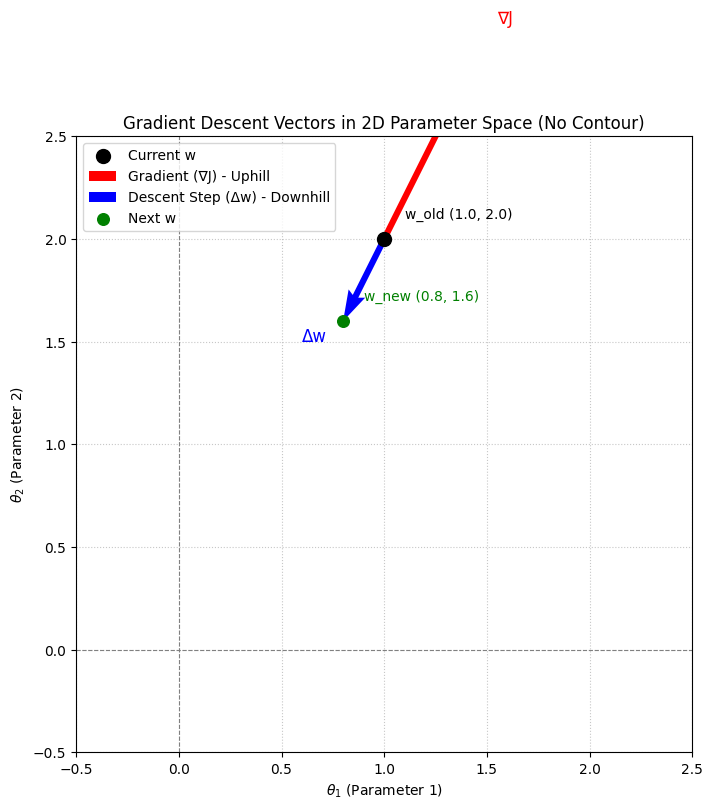

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Gradient of J(x, y) for a hypothetical J(x,y) = x^2 + y^2
def grad_J(x, y):
    return np.array([2 * x, 2 * y])

# Current position (w_old) in parameter space
w_old = np.array([1.0, 2.0])
# Learning rate (alpha)
alpha = 0.1

# Calculate the Gradient vector at the current position
gradient_vector = grad_J(w_old[0], w_old[1])

# Calculate the Descent Step vector (Δw)
delta_w = -alpha * gradient_vector

# Calculate the new position after the step
w_new = w_old + delta_w

# --- Plotting in 2D Parameter Space ---
plt.figure(figsize=(8, 8))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlim(-0.5, 2.5) # Adjusted limits for better focus
plt.ylim(-0.5, 2.5)

# Plot Current Position (w_old)
plt.scatter(w_old[0], w_old[1], color='black', s=100, zorder=5, label='Current w')

# Plot Gradient Vector (∇J) - scaled for visibility
# It originates from w_old and points in the direction of steepest *uphill* in J
gradient_scaled_for_plot = gradient_vector * 0.25 # Scale factor for visual length
plt.quiver(w_old[0], w_old[1], gradient_scaled_for_plot[0], gradient_scaled_for_plot[1],
           angles='xy', scale_units='xy', scale=1, color='red', width=0.01,
           label='Gradient (∇J) - Uphill')

# Plot Delta w vector (Δw) - This is the step we take for descent
# It originates from w_old and points in the direction of steepest *downhill* in J
plt.quiver(w_old[0], w_old[1], delta_w[0], delta_w[1],
           angles='xy', scale_units='xy', scale=1, color='blue', width=0.01,
           label='Descent Step (Δw) - Downhill')

# Plot Next Position (w_new)
plt.scatter(w_new[0], w_new[1], color='green', s=70, zorder=5, label='Next w')


# Annotations
plt.text(w_old[0] + 0.1, w_old[1] + 0.1, f'w_old ({w_old[0]:.1f}, {w_old[1]:.1f})', 
         color='black', fontsize=10)
plt.text(w_new[0] + 0.1, w_new[1] + 0.1, f'w_new ({w_new[0]:.1f}, {w_new[1]:.1f})', 
         color='green', fontsize=10)
plt.text(w_old[0] + gradient_scaled_for_plot[0] + 0.05, w_old[1] + gradient_scaled_for_plot[1] + 0.05, 
         '∇J', color='red', fontsize=12)
plt.text(w_old[0] + delta_w[0] - 0.2, w_old[1] + delta_w[1] - 0.1, 
         'Δw', color='blue', fontsize=12)


plt.title('Gradient Descent Vectors in 2D Parameter Space (No Contour)')
plt.xlabel(r'$\theta_1$ (Parameter 1)')
plt.ylabel(r'$\theta_2$ (Parameter 2)')
plt.legend(loc='upper left')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.7)

plt.savefig('gradient_descent_vectors_2d_no_contour.png')

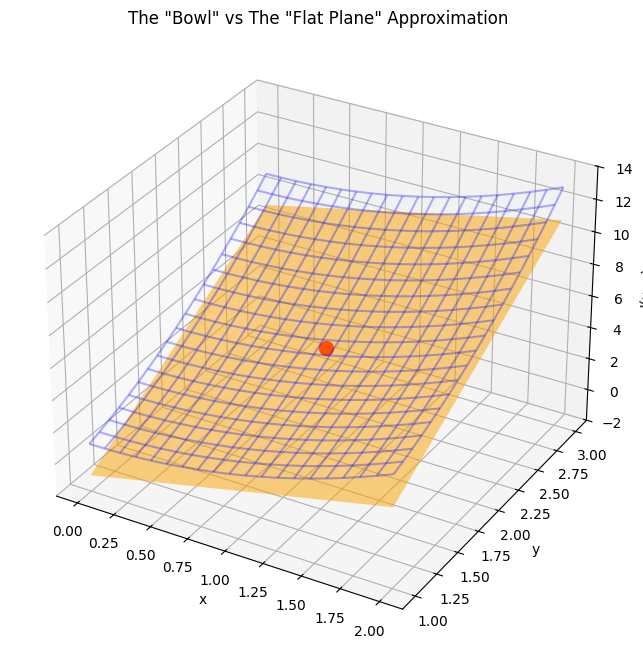

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Bowl (True Function)
def J(x, y):
    return x**2 + y**2

# 2. Define the Plane (Taylor Approximation)
# Approximating near (1, 2) where J=5, grad=[2, 4]
def Plane(dx, dy):
    return 5 + 2*dx + 4*dy

# Grid for plotting
x = np.linspace(0, 2, 20)
y = np.linspace(1, 3, 20)
X, Y = np.meshgrid(x, y)

# True Surface Z
Z_bowl = J(X, Y)

# Approximate Surface Z (Calculated using deltas from 1, 2)
# dx = X - 1, dy = Y - 2
Z_plane = Plane(X - 1, Y - 2)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Bowl (Wireframe)
ax.plot_wireframe(X, Y, Z_bowl, color='blue', alpha=0.3, label='True Function (Bowl)')

# Plot Plane (Surface)
ax.plot_surface(X, Y, Z_plane, color='orange', alpha=0.5, label='Taylor Plane')

# Point of contact
ax.scatter(1, 2, 5, color='red', s=100, label='Point (1, 2)')

ax.set_title('The "Bowl" vs The "Flat Plane" Approximation')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('J(x, y)')
plt.show()

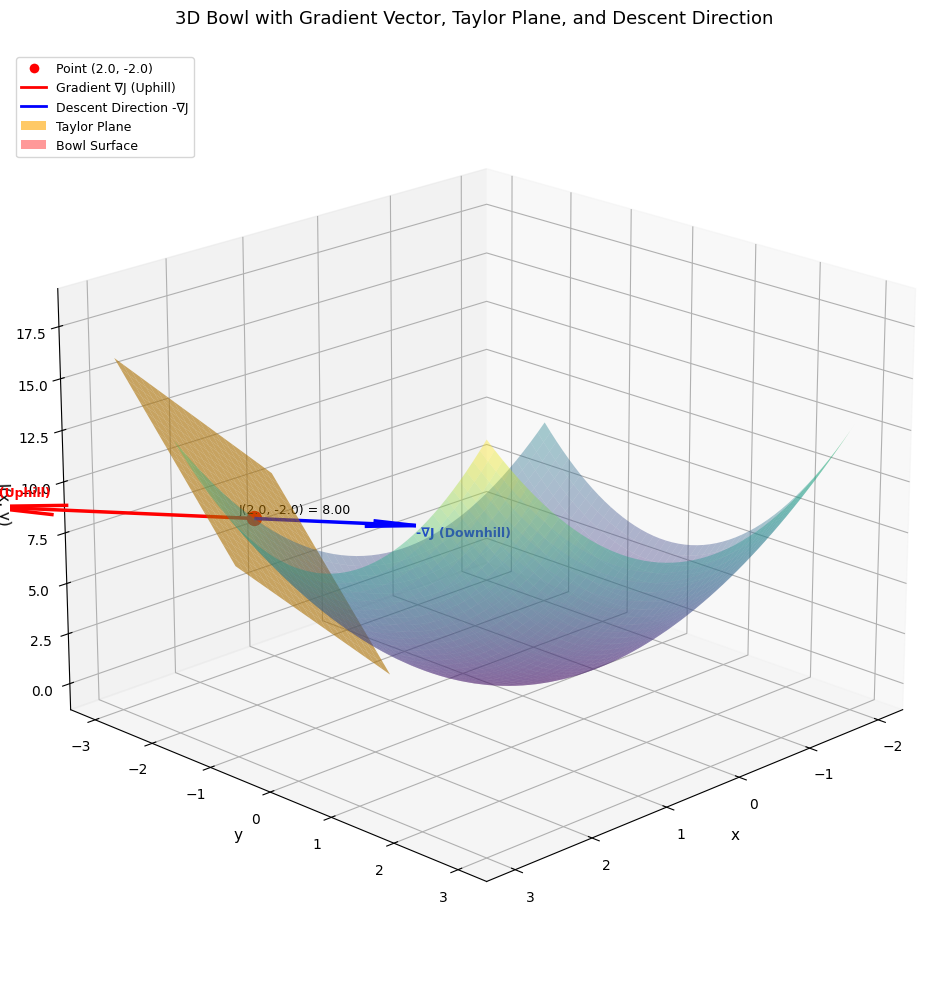

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the bowl function
def J(x, y):
    return x**2 + y**2

# Define the gradient at any point
def grad_J(x, y):
    return np.array([2*x, 2*y])

# Choose a point on the bowl
x0, y0 = 2.0, -2.0
z0 = J(x0, y0)

# Calculate gradient at this point
gradient = grad_J(x0, y0)

# Define the Taylor plane (first-order approximation)
def taylor_plane(x, y, x0, y0, z0, grad):
    return z0 + grad[0]*(x - x0) + grad[1]*(y - y0)

# Create grid for plotting
x = np.linspace(-2, 3, 50)
y = np.linspace(-2, 3, 50)
X, Y = np.meshgrid(x, y)

# Calculate Z values
Z_bowl = J(X, Y)
Z_plane = taylor_plane(X, Y, x0, y0, z0, gradient)

# Calculate gradient descent direction (opposite to gradient)
descent_direction = -gradient
# Scale for visualization
scale_gradient = 0.5
scale_descent = 0.3

# Create the 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the bowl surface
ax.plot_surface(X, Y, Z_bowl, alpha=0.4, cmap='viridis', edgecolor='none')

# Plot the Taylor plane (limited area around the point)
x_plane = np.linspace(x0-1, x0+1, 20)
y_plane = np.linspace(y0-1, y0+1, 20)
X_plane, Y_plane = np.meshgrid(x_plane, y_plane)
Z_plane_limited = taylor_plane(X_plane, Y_plane, x0, y0, z0, gradient)
ax.plot_surface(X_plane, Y_plane, Z_plane_limited, alpha=0.6, color='orange', label='Taylor Plane')

# Plot the point of interest
ax.scatter([x0], [y0], [z0], color='red', s=100, label=f'Point ({x0}, {y0})', zorder=5)

# Plot gradient vector (uphill direction)
ax.quiver(x0, y0, z0, 
          gradient[0]*scale_gradient, gradient[1]*scale_gradient, 2*scale_gradient,
          color='red', arrow_length_ratio=0.3, linewidth=2.5, label='Gradient (∇J) - Uphill')

# Plot gradient descent direction (downhill direction)
ax.quiver(x0, y0, z0,
          descent_direction[0]*scale_descent, descent_direction[1]*scale_descent, -2*scale_descent,
          color='blue', arrow_length_ratio=0.3, linewidth=2.5, label='Descent Direction')

# Labels and title
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('y', fontsize=11)
ax.set_zlabel('J(x, y)', fontsize=11)
ax.set_title('3D Bowl with Gradient Vector, Taylor Plane, and Descent Direction', fontsize=13, pad=20)

# Add text annotations
ax.text(x0 + 0.2, y0, z0 + 0.5, f'J({x0}, {y0}) = {z0:.2f}', fontsize=9)
ax.text(x0 + gradient[0]*scale_gradient, y0 + gradient[1]*scale_gradient, z0 + 2*scale_gradient + 0.5, 
        '∇J (Uphill)', color='red', fontsize=9, weight='bold')
ax.text(x0 + descent_direction[0]*scale_descent, y0 + descent_direction[1]*scale_descent, 
        z0 - 2*scale_descent - 0.5, '-∇J (Downhill)', color='blue', fontsize=9, weight='bold')

# Set viewing angle
ax.view_init(elev=20, azim=45)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label=f'Point ({x0}, {y0})'),
    Line2D([0], [0], color='red', linewidth=2, label='Gradient ∇J (Uphill)'),
    Line2D([0], [0], color='blue', linewidth=2, label='Descent Direction -∇J'),
    plt.Rectangle((0, 0), 1, 1, fc='orange', alpha=0.6, label='Taylor Plane'),
    plt.Rectangle((0, 0), 1, 1, fc='red', alpha=0.4, label='Bowl Surface')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
2*2*0.3, 2*-2*0.3
2-1.2, -2+1.2

(0.8, -0.8)

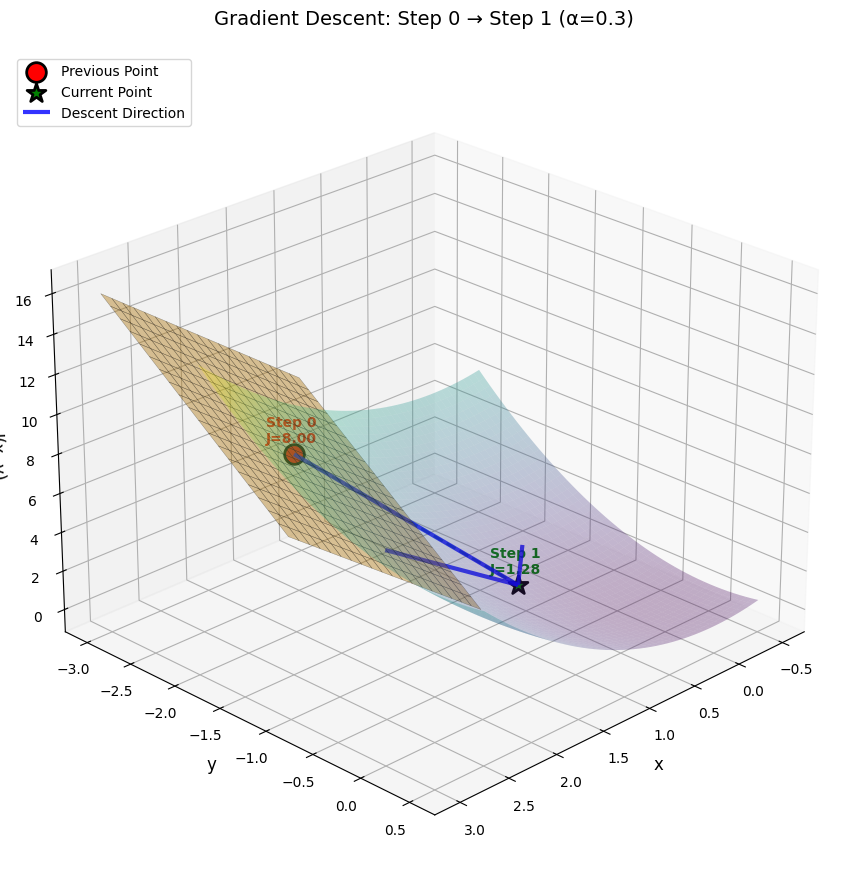


Step 0 → Step 1:
  From: x=2.0000, y=-2.0000, J=8.0000
  To:   x=0.8000, y=-0.8000, J=1.2800
  Change in J: -6.7200


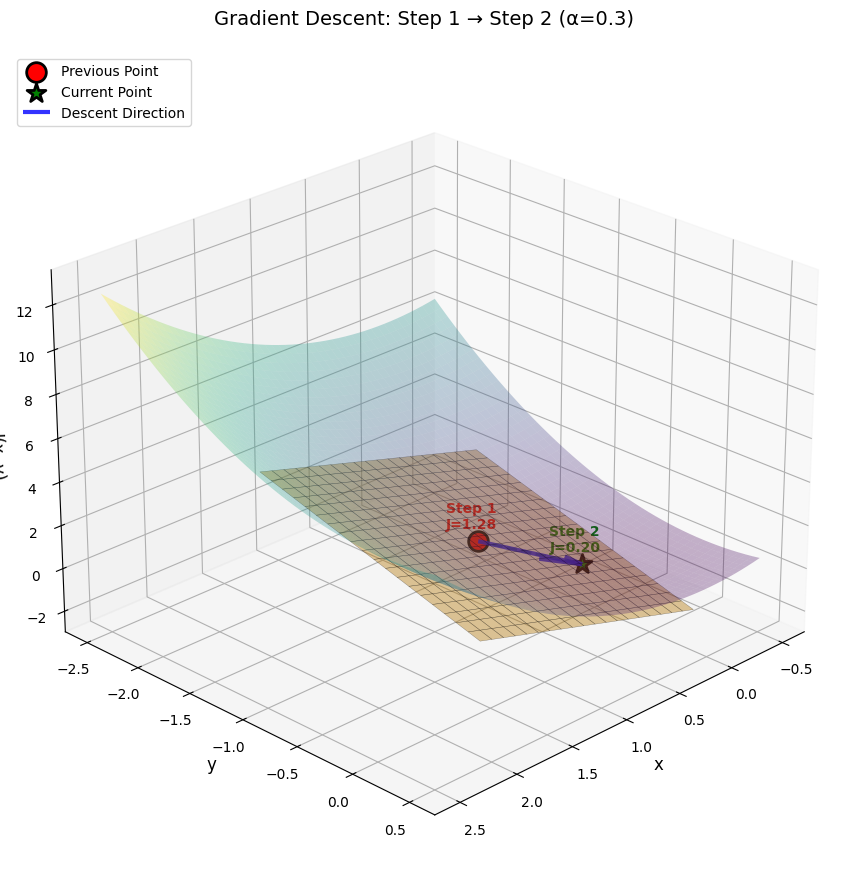


Step 1 → Step 2:
  From: x=0.8000, y=-0.8000, J=1.2800
  To:   x=0.3200, y=-0.3200, J=0.2048
  Change in J: -1.0752


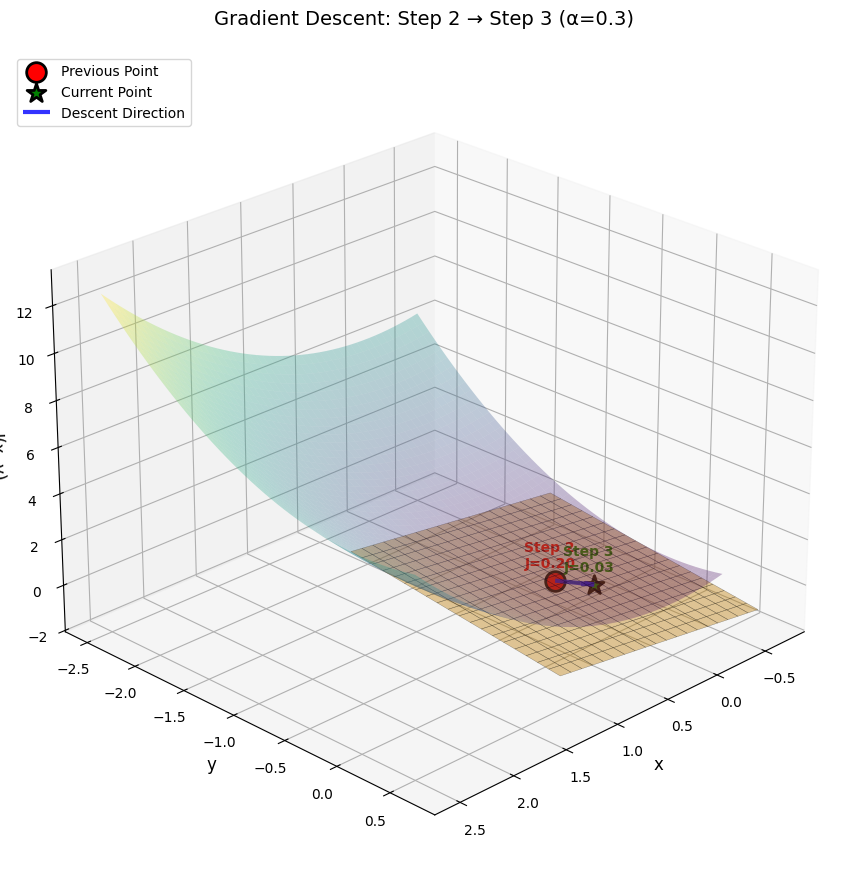


Step 2 → Step 3:
  From: x=0.3200, y=-0.3200, J=0.2048
  To:   x=0.1280, y=-0.1280, J=0.0328
  Change in J: -0.1720


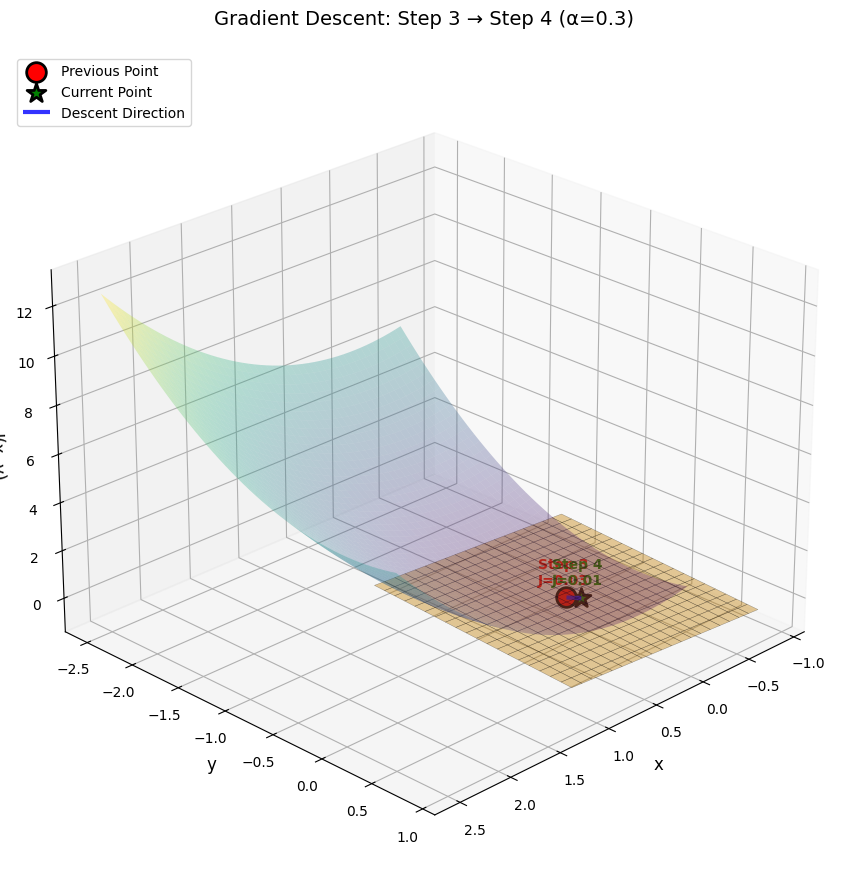


Step 3 → Step 4:
  From: x=0.1280, y=-0.1280, J=0.0328
  To:   x=0.0512, y=-0.0512, J=0.0052
  Change in J: -0.0275


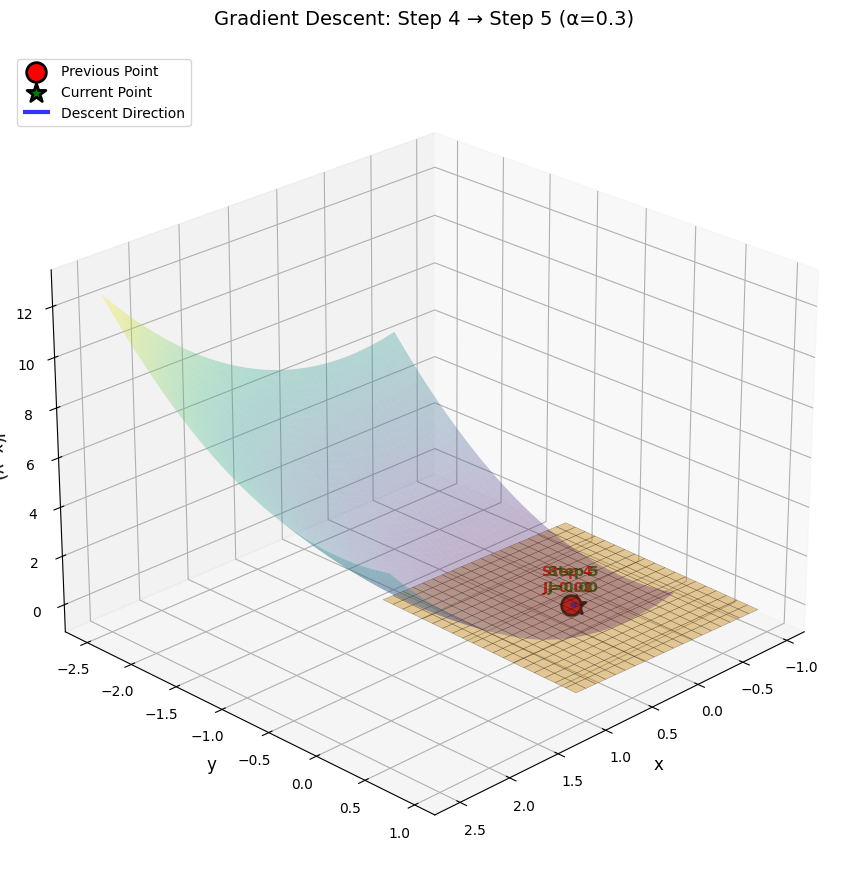


Step 4 → Step 5:
  From: x=0.0512, y=-0.0512, J=0.0052
  To:   x=0.0205, y=-0.0205, J=0.0008
  Change in J: -0.0044


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the bowl function
def J(x, y):
    return x**2 + y**2

# Define the gradient at any point
def grad_J(x, y):
    return np.array([2*x, 2*y])

# Starting point on the bowl
x0, y0 = 2.0, -2.0
z0 = J(x0, y0)

# Learning rate (step size)
alpha = 0.3

# Perform 5 gradient descent steps
num_steps = 5
points = [(x0, y0, z0)]  # Store all points

x_current, y_current = x0, y0

for step in range(num_steps):
    # Calculate gradient at current position
    gradient = grad_J(x_current, y_current)
    
    # Update position using gradient descent
    x_current = x_current - alpha * gradient[0]
    y_current = y_current - alpha * gradient[1]
    z_current = J(x_current, y_current)
    
    # Store the new point
    points.append((x_current, y_current, z_current))

# Create grid for plotting
x = np.linspace(-0.5, 2.5, 50)
y = np.linspace(-2.5, 0.5, 50)
X, Y = np.meshgrid(x, y)
Z_bowl = J(X, Y)

# Create a separate plot for each step
for step_num in range(1, len(points)):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the bowl surface
    ax.plot_surface(X, Y, Z_bowl, alpha=0.3, cmap='viridis', edgecolor='none')
    
    # Get previous and current points
    x_prev, y_prev, z_prev = points[step_num - 1]
    x_curr, y_curr, z_curr = points[step_num]
    
    # Plot the Taylor plane at the previous point
    gradient_prev = grad_J(x_prev, y_prev)
    def taylor_plane(x, y, x0, y0, z0, grad):
        return z0 + grad[0]*(x - x0) + grad[1]*(y - y0)
    
    x_plane = np.linspace(x_prev-1, x_prev+1, 20)
    y_plane = np.linspace(y_prev-1, y_prev+1, 20)
    X_plane, Y_plane = np.meshgrid(x_plane, y_plane)
    Z_plane_limited = taylor_plane(X_plane, Y_plane, x_prev, y_prev, z_prev, gradient_prev)
    ax.plot_surface(X_plane, Y_plane, Z_plane_limited, alpha=0.4, color='orange', edgecolor='k', linewidth=0.3)
    
    # Plot previous point
    ax.scatter([x_prev], [y_prev], [z_prev], color='red', s=200, 
               edgecolor='black', linewidth=2, zorder=5, label='Previous Point')
    ax.text(x_prev + 0.1, y_prev - 0.2, z_prev + 0.4, 
            f'Step {step_num-1}\nJ={z_prev:.2f}', 
            fontsize=10, color='red', weight='bold')
    
    # Plot current point
    ax.scatter([x_curr], [y_curr], [z_curr], color='green', s=200, marker='*',
               edgecolor='black', linewidth=2, zorder=5, label='Current Point')
    ax.text(x_curr + 0.1, y_curr - 0.2, z_curr + 0.4, 
            f'Step {step_num}\nJ={z_curr:.2f}', 
            fontsize=10, color='green', weight='bold')
    
    # Draw arrow from previous to current point
    dx = x_curr - x_prev
    dy = y_curr - y_prev
    dz = z_curr - z_prev
    
    ax.quiver(x_prev, y_prev, z_prev, dx, dy, dz,
              color='blue', arrow_length_ratio=0.3, linewidth=3, alpha=0.8,
              label='Descent Direction')
    
    # Draw line connecting the two points
    ax.plot([x_prev, x_curr], [y_prev, y_curr], [z_prev, z_curr], 
            'g--', linewidth=2, alpha=0.7)
    
    # Labels and title
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_zlabel('J(x, y)', fontsize=12)
    ax.set_title(f'Gradient Descent: Step {step_num-1} → Step {step_num} (α={alpha})', 
                 fontsize=14, pad=20)
    
    # Set viewing angle
    ax.view_init(elev=25, azim=45)
    
    # Add legend
    ax.legend(loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print the step information
    print(f"\nStep {step_num-1} → Step {step_num}:")
    print(f"  From: x={x_prev:.4f}, y={y_prev:.4f}, J={z_prev:.4f}")
    print(f"  To:   x={x_curr:.4f}, y={y_curr:.4f}, J={z_curr:.4f}")
    print(f"  Change in J: {z_curr - z_prev:.4f}")